# Setup Libraries

In [1]:
%%time
!pip install -q --no-index -U --find-links=/kaggle/input/tensorflow-2-15/tensorflow tensorflow==2.15.0
!pip install -q --no-index -U --find-links=/kaggle/input/deeptables-v0-2-5/deeptables-0.2.5 deeptables==0.2.5
!pip install -q --no-index -U --find-links=/kaggle/input/fix-deeptables/deeptables-0.2.6 deeptables==0.2.6

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.10.0 requires tensorflow==2.17.0, but you have tensorflow 2.15.0 which is incompatible.
tensorflow-text 2.17.0 requires tensorflow<2.18,>=2.17.0, but you have tensorflow 2.15.0 which is incompatible.
tensorstore 0.1.71 requires ml_dtypes>=0.3.1, but you have ml-dtypes 0.2.0 which is incompatible.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.15.0 which is incompatible.
CPU times: user 1.17 s, sys: 261 ms, total: 1.43 s
Wall time: 1min 32s


In [2]:
import os
import gc
import shap
import math
import ctypes
import random
import warnings
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from colorama import Fore, Style
from numpy.typing import ArrayLike
from sklearn.base import BaseEstimator
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold

import tensorflow as tf, deeptables as dt
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.callbacks import EarlyStopping
from deeptables.utils.shap import DeepTablesExplainer
from deeptables.models import DeepTable, ModelConfig, deepnets

warnings.filterwarnings('ignore')
print("TensorFlow version:", tf.__version__ + ",",
      "GPU =", tf.test.is_gpu_available())
print("DeepTables version:", dt.__version__)

TensorFlow version: 2.15.0, GPU = True
DeepTables version: 0.2.6


In [3]:
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
seed_everything(seed=42)

def clean_memory():
    gc.collect()
    ctypes.CDLL('libc.so.6').malloc_trim(0)
clean_memory()

# Load Data

In [4]:
train = pd.read_csv("/kaggle/input/playground-series-s5e8/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e8/test.csv")
original = pd.read_csv("/kaggle/input/bank-marketing-dataset-full/bank-full.csv", sep=';')
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Orig shape:", original.shape)

Train shape: (750000, 18)
Test shape: (250000, 17)
Orig shape: (45211, 17)


# Preprocess Features

In [5]:
%%time
X = train.drop(['id', 'y'], axis=1)
y = train.y; train_id = train.id; mean = train['y'].mean() 
X_test = test.drop(['id'], axis=1)
original['y'] = original['y'].map({'no': 0, 'yes': 1})
del train, test; clean_memory()
print("X      shape:", X.shape)
print("X_test shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

def feature_engineering(df):
    df['duration_long_'] = (df['duration'] > 300).astype('category')
    df['_duration_sqrt'] = np.sqrt(df['duration']).astype('float32')
    df['_duration_sin'] = np.sin(2*np.pi * df['duration'] / 540).astype('float32')
    df['_duration_cos'] = np.cos(2*np.pi * df['duration'] / 540).astype('float32')
    df['_balance_log'] = (np.sign(df['balance']) * np.log1p(np.abs(df['balance']))).astype('float32')
    df['_balance_sin'] = np.sin(2*np.pi * df['balance'] / 1000).astype('float32')
    df['_balance_cos'] = np.cos(2*np.pi * df['balance'] / 1000).astype('float32')
    df['_age_sin'] = np.sin(2*np.pi * df['age'] / 10).astype('float32')
    df['_pdays_sin'] = np.sin(2*np.pi * df['pdays'] / 7).astype('float32')
    month_map = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
                 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}
    df['month_num'] = df['month'].map(month_map)
    df['_month_sin'] = np.sin(2*np.pi * df['month_num'] / 12).astype('float32')
    df = df.drop(['month_num'], axis=1)

    for c in cat_cols+num_cols:
        new_col = f"._{c}_mean_target_orig"
        df[new_col] = (
            df[c]
            .map(original.groupby(c)['y'].mean())
            .fillna(mean)
            .astype('float32')
        )

        mapping_count = original[c].value_counts()
        df[f"._{c}_count"] = (
            df[c]
            .map(mapping_count)
            .fillna(0)
            .astype('float32')
        )
    
    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    new_enc_cols = [col for col in df.columns if col.startswith('.')]
    return df, new_cat_cols, new_num_cols, new_enc_cols

X, new_cat_cols, new_num_cols, new_enc_cols = feature_engineering(X)
X_test, new_cat_cols, new_num_cols, new_enc_cols = feature_engineering(X_test)
num_cols += new_num_cols; cat_cols += new_cat_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols))
print("len(new_enc_cols):", len(new_enc_cols), "\n")

scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols]).astype(np.float32)
X_test[num_cols] = scaler.transform(X_test[num_cols]).astype(np.float32)
num_cols += new_enc_cols
print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
del original; clean_memory()

X      shape: (750000, 16)
X_test shape: (250000, 16) 

init len(cat_cols): 9
init len(num_cols): 7 

len(new_cat_cols): 1
len(new_num_cols): 9
len(new_enc_cols): 32 

prep len(cat_cols): 10
prep len(num_cols): 48 

CPU times: user 2.51 s, sys: 296 ms, total: 2.81 s
Wall time: 2.7 s


# DeepTables NN

## Learning Schedule

Learning rate schedule: 1e-05 to 0.001 to 1e-07


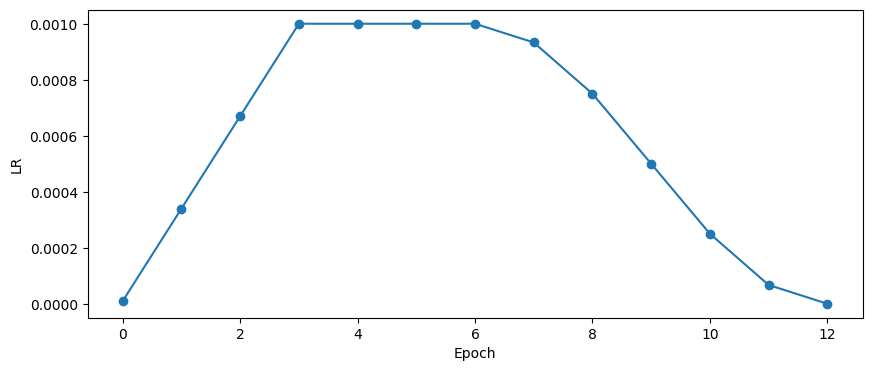

In [6]:
# One Cycle Cosine Annealing with Warm-up
LR_START = 1e-5
LR_MAX = 1e-3
LR_MIN = 1e-7
LR_RAMPUP_EPOCHS = 3
LR_SUSTAIN_EPOCHS = 3
EPOCHS = 13
PATIENCE = 3

def lrfn(epoch):
    if epoch < LR_RAMPUP_EPOCHS:
        lr = (LR_MAX - LR_START) / LR_RAMPUP_EPOCHS * epoch + LR_START
    elif epoch < LR_RAMPUP_EPOCHS + LR_SUSTAIN_EPOCHS:
        lr = LR_MAX
    else:
        decay_total_epochs = EPOCHS - LR_RAMPUP_EPOCHS - LR_SUSTAIN_EPOCHS - 1
        decay_epoch_index = epoch - LR_RAMPUP_EPOCHS - LR_SUSTAIN_EPOCHS
        phase = math.pi * decay_epoch_index / decay_total_epochs
        cosine_decay = 0.5 * (1 + math.cos(phase))
        lr = (LR_MAX - LR_MIN) * cosine_decay + LR_MIN    
    return lr

rng = [i for i in range(EPOCHS)]
lr_y = [lrfn(x) for x in rng]
plt.figure(figsize=(10, 4))
plt.plot(rng, lr_y, '-o')
plt.xlabel('Epoch'); plt.ylabel('LR')
print("Learning rate schedule: {:.3g} to {:.3g} to {:.3g}". \
      format(lr_y[0], max(lr_y), lr_y[-1]))

LR_Scheduler = tf.keras.callbacks.LearningRateScheduler(lrfn, verbose=False)
E_Stopping = EarlyStopping(patience=PATIENCE, verbose=1, restore_best_weights=True)

## Model Definition

In [7]:
class CFG:
    TRAIN = True
    FIT_VERBOSE = 2
    folds = 7
    epochs = 13
    batch_size = 128
    optimizer = Adam(learning_rate=1e-3)
    callbacks = [LR_Scheduler, E_Stopping]  

    conf = ModelConfig(auto_imputation=False,
                       auto_categorize=True,
                       auto_discrete=True,
                       fixed_embedding_dim=True,
                       embeddings_output_dim=4,
                       embedding_dropout=0.30,
                       nets=['dnn_nets'],
                       dnn_params={
                           'hidden_units': ((768, 0.30, True),
                                            (384, 0.25, True),
                                            (192, 0.20, True)),
                           'dnn_activation': 'relu',
                       },
                       stacking_op='concat',
                       output_use_bias=False,
                       optimizer=optimizer,
                       task='binary',
                       loss='auto',
                       metrics=['AUC'],
                       )

## Train K-Fold

Data shape: (750000, 58) 

#########################
### Fold 1/7 ...
#########################
08-23 20:41:19 I deeptables.m.deeptable.py 338 - X.Shape=(642857, 58), y.Shape=(642857,), batch_size=128, config=ModelConfig(name='conf-1', nets=['dnn_nets', 'fg_nets'], categorical_columns='auto', exclude_columns=[], task='binary', pos_label=None, metrics=['AUC'], auto_categorize=True, cat_exponent=0.5, cat_remain_numeric=True, auto_encode_label=True, auto_imputation=False, auto_scale=False, auto_discrete=True, auto_discard_unique=True, apply_gbm_features=False, gbm_params={}, gbm_feature_type='embedding', fixed_embedding_dim=True, embeddings_output_dim=4, embeddings_initializer='uniform', embeddings_regularizer=None, embeddings_activity_regularizer=None, dense_dropout=0, embedding_dropout=0.3, stacking_op='concat', output_use_bias=False, apply_class_weight=False, optimizer=<keras.src.optimizers.legacy.adam.Adam object at 0x7a81e656e9e0>, loss='auto', dnn_params={'hidden_units': ((768, 0.3,

08-23 20:41:20 W hypernets.t.cache.py 210 - AttributeError: Can't pickle local object 'make_gradient_clipnorm_fn.<locals>.<lambda>'
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/cache.py", line 165, in _cache_call
    cache_key = tb.data_hasher()(key_items)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 20, in __call__
    for x in self._iter_data(data):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 58, in _iter_data
    yield from self._iter_data(v)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 53, in _iter_data
    yield from self._iter_data(x)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 61, in _iter_data
    pickle.dump(data, buf, protocol=pickle.HIGHEST_PROTOCOL)



08-23 20:41:20 I deeptables.m.preprocessor.py 263 - Preparing features...
08-23 20:41:37 I deeptables.m.preprocessor.py 338 - Preparing features taken 16.571495056152344s
08-23 20:41:37 I deeptables.m.preprocessor.py 390 - Categorical encoding...
08-23 20:41:44 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 7.374895334243774s
08-23 20:41:44 I deeptables.m.preprocessor.py 411 - Data discretization...
08-23 20:41:44 I hypernets.t.sklearn_ex.py 716 - 48 variables to discrete.
08-23 20:41:46 I deeptables.m.preprocessor.py 417 - Discretization taken 1.5694494247436523s
08-23 20:41:47 I deeptables.m.preprocessor.py 198 - fit_transform taken 26.847038507461548s
08-23 20:41:47 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-23 20:41:51 I deeptables.m.preprocessor.py 251 - transform_X taken 4.035771608352661s
08-23 20:41:51 I deeptables.m.preprocessor.py 232 - Transform [y]...
08-23 20:41:51 I deeptables.m.preprocessor.py 238 - transform_y taken 0.005104541778564453s
0

08-23 21:00:44 W hypernets.t.cache.py 210 - AttributeError: Can't pickle local object 'make_gradient_clipnorm_fn.<locals>.<lambda>'
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/cache.py", line 165, in _cache_call
    cache_key = tb.data_hasher()(key_items)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 20, in __call__
    for x in self._iter_data(data):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 58, in _iter_data
    yield from self._iter_data(v)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 53, in _iter_data
    yield from self._iter_data(x)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 61, in _iter_data
    pickle.dump(data, buf, protocol=pickle.HIGHEST_PROTOCOL)



08-23 21:00:44 I deeptables.m.preprocessor.py 263 - Preparing features...
08-23 21:01:00 I deeptables.m.preprocessor.py 338 - Preparing features taken 15.946320056915283s
08-23 21:01:00 I deeptables.m.preprocessor.py 390 - Categorical encoding...
08-23 21:01:08 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 7.557206869125366s
08-23 21:01:08 I deeptables.m.preprocessor.py 411 - Data discretization...
08-23 21:01:08 I hypernets.t.sklearn_ex.py 716 - 48 variables to discrete.
08-23 21:01:09 I deeptables.m.preprocessor.py 417 - Discretization taken 1.4718306064605713s
08-23 21:01:10 I deeptables.m.preprocessor.py 198 - fit_transform taken 26.077741861343384s
08-23 21:01:10 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-23 21:01:14 I deeptables.m.preprocessor.py 251 - transform_X taken 3.968165636062622s
08-23 21:01:14 I deeptables.m.preprocessor.py 232 - Transform [y]...
08-23 21:01:14 I deeptables.m.preprocessor.py 238 - transform_y taken 0.00446629524230957s
08

...

08-23 21:58:11 I deeptables.m.preprocessor.py 263 - Preparing features...
08-23 21:58:27 I deeptables.m.preprocessor.py 338 - Preparing features taken 16.06368088722229s
08-23 21:58:27 I deeptables.m.preprocessor.py 390 - Categorical encoding...
08-23 21:58:34 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 7.527917385101318s
08-23 21:58:34 I deeptables.m.preprocessor.py 411 - Data discretization...
08-23 21:58:34 I hypernets.t.sklearn_ex.py 716 - 48 variables to discrete.
08-23 21:58:36 I deeptables.m.preprocessor.py 417 - Discretization taken 1.4659783840179443s
08-23 21:58:37 I deeptables.m.preprocessor.py 198 - fit_transform taken 26.074132442474365s
08-23 21:58:37 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-23 21:58:41 I deeptables.m.preprocessor.py 251 - transform_X taken 3.8892617225646973s
08-23 21:58:41 I deeptables.m.preprocessor.py 232 - Transform [y]...
08-23 21:58:41 I deeptables.m.preprocessor.py 238 - transform_y taken 0.004380702972412109s
0

08-23 22:17:17 W hypernets.t.cache.py 210 - AttributeError: Can't pickle local object 'make_gradient_clipnorm_fn.<locals>.<lambda>'
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/cache.py", line 165, in _cache_call
    cache_key = tb.data_hasher()(key_items)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 20, in __call__
    for x in self._iter_data(data):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 58, in _iter_data
    yield from self._iter_data(v)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 53, in _iter_data
    yield from self._iter_data(x)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 61, in _iter_data
    pickle.dump(data, buf, protocol=pickle.HIGHEST_PROTOCOL)



08-23 22:17:17 I deeptables.m.preprocessor.py 263 - Preparing features...
08-23 22:17:33 I deeptables.m.preprocessor.py 338 - Preparing features taken 15.964990854263306s
08-23 22:17:33 I deeptables.m.preprocessor.py 390 - Categorical encoding...
08-23 22:17:41 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 7.676910400390625s
08-23 22:17:41 I deeptables.m.preprocessor.py 411 - Data discretization...
08-23 22:17:41 I hypernets.t.sklearn_ex.py 716 - 48 variables to discrete.
08-23 22:17:42 I deeptables.m.preprocessor.py 417 - Discretization taken 1.503110647201538s
08-23 22:17:43 I deeptables.m.preprocessor.py 198 - fit_transform taken 26.162571668624878s
08-23 22:17:43 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-23 22:17:47 I deeptables.m.preprocessor.py 251 - transform_X taken 3.956610679626465s
08-23 22:17:47 I deeptables.m.preprocessor.py 232 - Transform [y]...
08-23 22:17:47 I deeptables.m.preprocessor.py 238 - transform_y taken 0.004816770553588867s
08

08-23 22:36:25 W hypernets.t.cache.py 210 - AttributeError: Can't pickle local object 'make_gradient_clipnorm_fn.<locals>.<lambda>'
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/cache.py", line 165, in _cache_call
    cache_key = tb.data_hasher()(key_items)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 20, in __call__
    for x in self._iter_data(data):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 58, in _iter_data
    yield from self._iter_data(v)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 53, in _iter_data
    yield from self._iter_data(x)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 61, in _iter_data
    pickle.dump(data, buf, protocol=pickle.HIGHEST_PROTOCOL)



08-23 22:36:26 I deeptables.m.preprocessor.py 263 - Preparing features...
08-23 22:36:42 I deeptables.m.preprocessor.py 338 - Preparing features taken 15.866155862808228s
08-23 22:36:42 I deeptables.m.preprocessor.py 390 - Categorical encoding...
08-23 22:36:49 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 7.5452964305877686s
08-23 22:36:49 I deeptables.m.preprocessor.py 411 - Data discretization...
08-23 22:36:49 I hypernets.t.sklearn_ex.py 716 - 48 variables to discrete.
08-23 22:36:51 I deeptables.m.preprocessor.py 417 - Discretization taken 1.4648988246917725s
08-23 22:36:51 I deeptables.m.preprocessor.py 198 - fit_transform taken 25.83544921875s
08-23 22:36:51 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-23 22:36:55 I deeptables.m.preprocessor.py 251 - transform_X taken 3.9106295108795166s
08-23 22:36:55 I deeptables.m.preprocessor.py 232 - Transform [y]...
08-23 22:36:55 I deeptables.m.preprocessor.py 238 - transform_y taken 0.003898143768310547s
08-

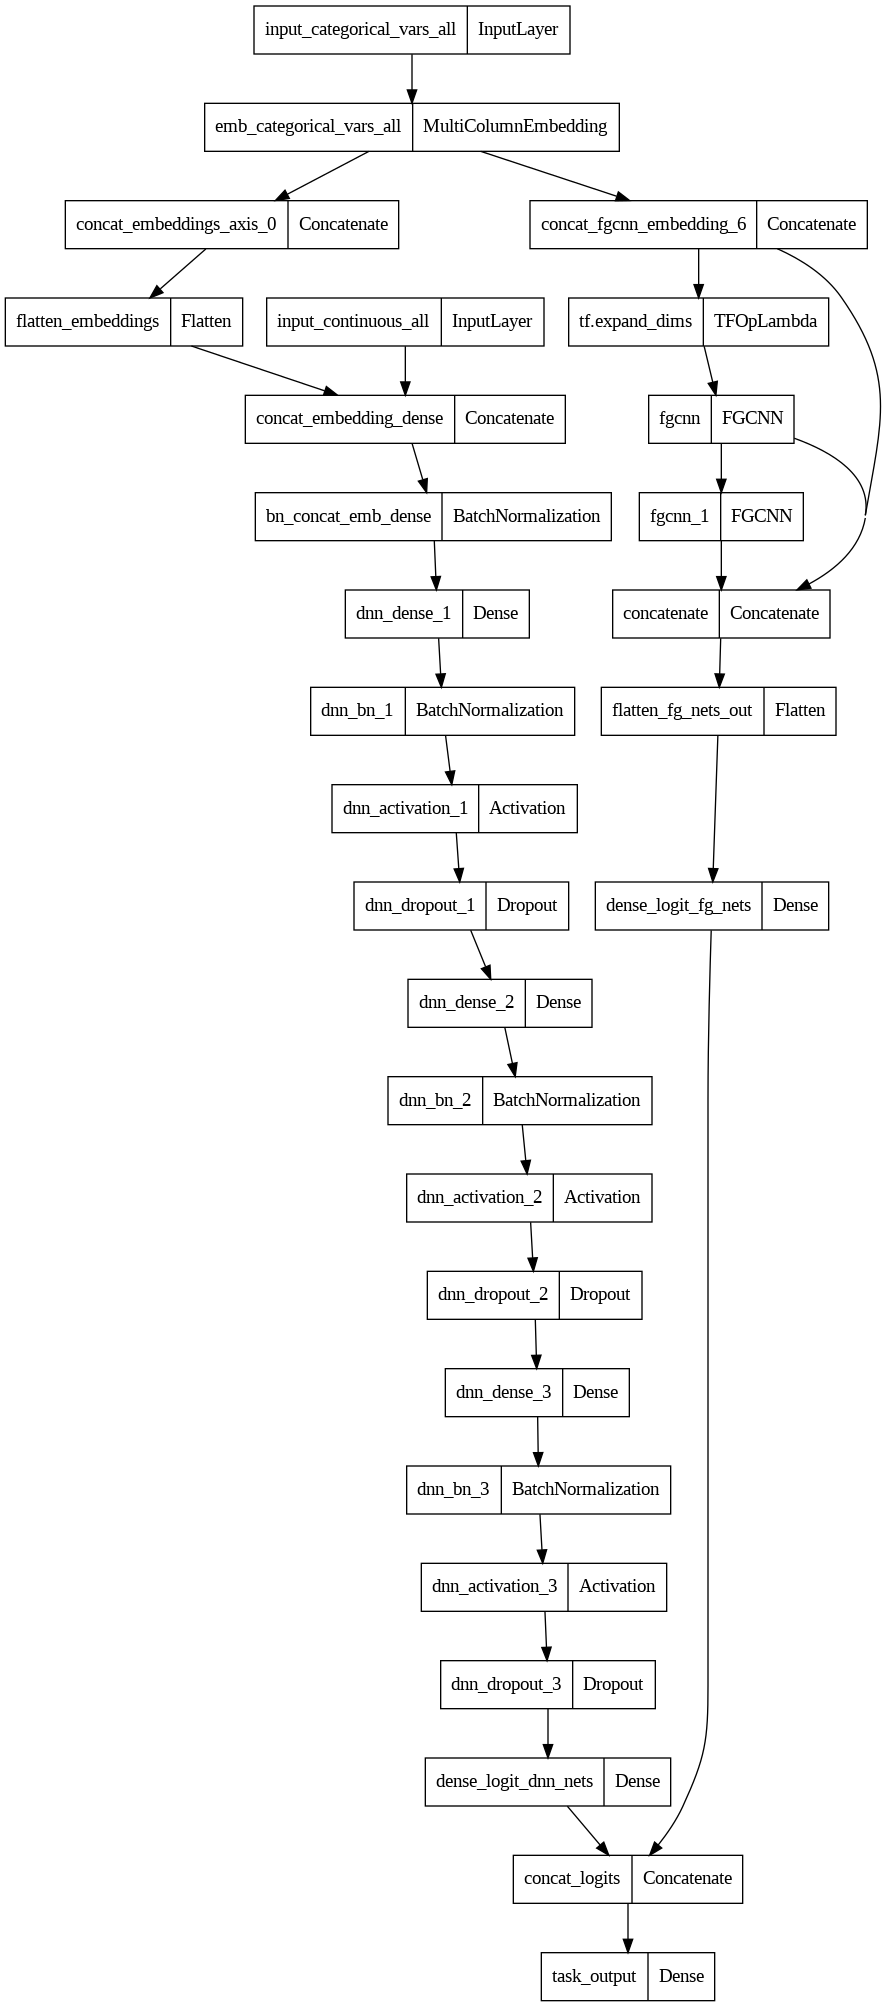

Data shape: (750000, 58) 

#########################
### Fold 1/7 ...
#########################
08-23 22:55:34 I deeptables.m.deeptable.py 338 - X.Shape=(642857, 58), y.Shape=(642857,), batch_size=128, config=ModelConfig(name='conf-1', nets=['dnn_nets', 'fm_nets'], categorical_columns='auto', exclude_columns=[], task='binary', pos_label=None, metrics=['AUC'], auto_categorize=True, cat_exponent=0.5, cat_remain_numeric=True, auto_encode_label=True, auto_imputation=False, auto_scale=False, auto_discrete=True, auto_discard_unique=True, apply_gbm_features=False, gbm_params={}, gbm_feature_type='embedding', fixed_embedding_dim=True, embeddings_output_dim=4, embeddings_initializer='uniform', embeddings_regularizer=None, embeddings_activity_regularizer=None, dense_dropout=0, embedding_dropout=0.3, stacking_op='concat', output_use_bias=False, apply_class_weight=False, optimizer=<keras.src.optimizers.legacy.adam.Adam object at 0x7a81e656e9e0>, loss='auto', dnn_params={'hidden_units': ((768, 0.3,

08-23 22:55:36 W hypernets.t.cache.py 210 - AttributeError: Can't pickle local object 'make_gradient_clipnorm_fn.<locals>.<lambda>'
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/cache.py", line 165, in _cache_call
    cache_key = tb.data_hasher()(key_items)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 20, in __call__
    for x in self._iter_data(data):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 58, in _iter_data
    yield from self._iter_data(v)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 53, in _iter_data
    yield from self._iter_data(x)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 61, in _iter_data
    pickle.dump(data, buf, protocol=pickle.HIGHEST_PROTOCOL)



08-23 22:55:36 I deeptables.m.preprocessor.py 263 - Preparing features...
08-23 22:55:52 I deeptables.m.preprocessor.py 338 - Preparing features taken 15.769357681274414s
08-23 22:55:52 I deeptables.m.preprocessor.py 390 - Categorical encoding...
08-23 22:56:00 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 7.551957845687866s
08-23 22:56:00 I deeptables.m.preprocessor.py 411 - Data discretization...
08-23 22:56:00 I hypernets.t.sklearn_ex.py 716 - 48 variables to discrete.
08-23 22:56:01 I deeptables.m.preprocessor.py 417 - Discretization taken 1.4698712825775146s
08-23 22:56:02 I deeptables.m.preprocessor.py 198 - fit_transform taken 25.80237078666687s
08-23 22:56:02 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-23 22:56:06 I deeptables.m.preprocessor.py 251 - transform_X taken 3.99123215675354s
08-23 22:56:06 I deeptables.m.preprocessor.py 232 - Transform [y]...
08-23 22:56:06 I deeptables.m.preprocessor.py 238 - transform_y taken 0.004631757736206055s
08-

08-23 23:14:16 W hypernets.t.cache.py 210 - AttributeError: Can't pickle local object 'make_gradient_clipnorm_fn.<locals>.<lambda>'
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/cache.py", line 165, in _cache_call
    cache_key = tb.data_hasher()(key_items)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 20, in __call__
    for x in self._iter_data(data):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 58, in _iter_data
    yield from self._iter_data(v)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 53, in _iter_data
    yield from self._iter_data(x)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 61, in _iter_data
    pickle.dump(data, buf, protocol=pickle.HIGHEST_PROTOCOL)



08-23 23:14:17 I deeptables.m.preprocessor.py 263 - Preparing features...
08-23 23:14:32 I deeptables.m.preprocessor.py 338 - Preparing features taken 15.676060914993286s
08-23 23:14:32 I deeptables.m.preprocessor.py 390 - Categorical encoding...
08-23 23:14:40 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 7.566998481750488s
08-23 23:14:40 I deeptables.m.preprocessor.py 411 - Data discretization...
08-23 23:14:40 I hypernets.t.sklearn_ex.py 716 - 48 variables to discrete.
08-23 23:14:41 I deeptables.m.preprocessor.py 417 - Discretization taken 1.457005500793457s
08-23 23:14:42 I deeptables.m.preprocessor.py 198 - fit_transform taken 25.673259496688843s
08-23 23:14:42 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-23 23:14:46 I deeptables.m.preprocessor.py 251 - transform_X taken 3.919794797897339s
08-23 23:14:46 I deeptables.m.preprocessor.py 232 - Transform [y]...
08-23 23:14:46 I deeptables.m.preprocessor.py 238 - transform_y taken 0.004742860794067383s
08

...

08-24 00:08:15 I deeptables.m.preprocessor.py 263 - Preparing features...
08-24 00:08:30 I deeptables.m.preprocessor.py 338 - Preparing features taken 15.774379253387451s
08-24 00:08:30 I deeptables.m.preprocessor.py 390 - Categorical encoding...
08-24 00:08:38 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 7.727092027664185s
08-24 00:08:38 I deeptables.m.preprocessor.py 411 - Data discretization...
08-24 00:08:38 I hypernets.t.sklearn_ex.py 716 - 48 variables to discrete.
08-24 00:08:40 I deeptables.m.preprocessor.py 417 - Discretization taken 1.5559072494506836s
08-24 00:08:41 I deeptables.m.preprocessor.py 198 - fit_transform taken 26.062415599822998s
08-24 00:08:41 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-24 00:08:45 I deeptables.m.preprocessor.py 251 - transform_X taken 4.087974786758423s
08-24 00:08:45 I deeptables.m.preprocessor.py 232 - Transform [y]...
08-24 00:08:45 I deeptables.m.preprocessor.py 238 - transform_y taken 0.00469207763671875s
08

08-24 00:26:07 W hypernets.t.cache.py 210 - AttributeError: Can't pickle local object 'make_gradient_clipnorm_fn.<locals>.<lambda>'
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/cache.py", line 165, in _cache_call
    cache_key = tb.data_hasher()(key_items)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 20, in __call__
    for x in self._iter_data(data):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 58, in _iter_data
    yield from self._iter_data(v)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 53, in _iter_data
    yield from self._iter_data(x)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 61, in _iter_data
    pickle.dump(data, buf, protocol=pickle.HIGHEST_PROTOCOL)



08-24 00:26:07 I deeptables.m.preprocessor.py 263 - Preparing features...
08-24 00:26:23 I deeptables.m.preprocessor.py 338 - Preparing features taken 15.45447325706482s
08-24 00:26:23 I deeptables.m.preprocessor.py 390 - Categorical encoding...
08-24 00:26:30 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 7.551718235015869s
08-24 00:26:30 I deeptables.m.preprocessor.py 411 - Data discretization...
08-24 00:26:30 I hypernets.t.sklearn_ex.py 716 - 48 variables to discrete.
08-24 00:26:32 I deeptables.m.preprocessor.py 417 - Discretization taken 1.4454123973846436s
08-24 00:26:32 I deeptables.m.preprocessor.py 198 - fit_transform taken 25.44595980644226s
08-24 00:26:33 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-24 00:26:37 I deeptables.m.preprocessor.py 251 - transform_X taken 4.057065725326538s
08-24 00:26:37 I deeptables.m.preprocessor.py 232 - Transform [y]...
08-24 00:26:37 I deeptables.m.preprocessor.py 238 - transform_y taken 0.00426483154296875s
08-2

08-24 00:44:07 W hypernets.t.cache.py 210 - AttributeError: Can't pickle local object 'make_gradient_clipnorm_fn.<locals>.<lambda>'
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/cache.py", line 165, in _cache_call
    cache_key = tb.data_hasher()(key_items)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 20, in __call__
    for x in self._iter_data(data):
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 58, in _iter_data
    yield from self._iter_data(v)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 53, in _iter_data
    yield from self._iter_data(x)
  File "/usr/local/lib/python3.10/dist-packages/hypernets/tabular/data_hasher.py", line 61, in _iter_data
    pickle.dump(data, buf, protocol=pickle.HIGHEST_PROTOCOL)



08-24 00:44:07 I deeptables.m.preprocessor.py 263 - Preparing features...
08-24 00:44:22 I deeptables.m.preprocessor.py 338 - Preparing features taken 15.475801467895508s
08-24 00:44:22 I deeptables.m.preprocessor.py 390 - Categorical encoding...
08-24 00:44:30 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 7.575473308563232s
08-24 00:44:30 I deeptables.m.preprocessor.py 411 - Data discretization...
08-24 00:44:30 I hypernets.t.sklearn_ex.py 716 - 48 variables to discrete.
08-24 00:44:31 I deeptables.m.preprocessor.py 417 - Discretization taken 1.441577672958374s
08-24 00:44:32 I deeptables.m.preprocessor.py 198 - fit_transform taken 25.52651357650757s
08-24 00:44:32 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-24 00:44:36 I deeptables.m.preprocessor.py 251 - transform_X taken 3.9735605716705322s
08-24 00:44:36 I deeptables.m.preprocessor.py 232 - Transform [y]...
08-24 00:44:36 I deeptables.m.preprocessor.py 238 - transform_y taken 0.004908084869384766s
08

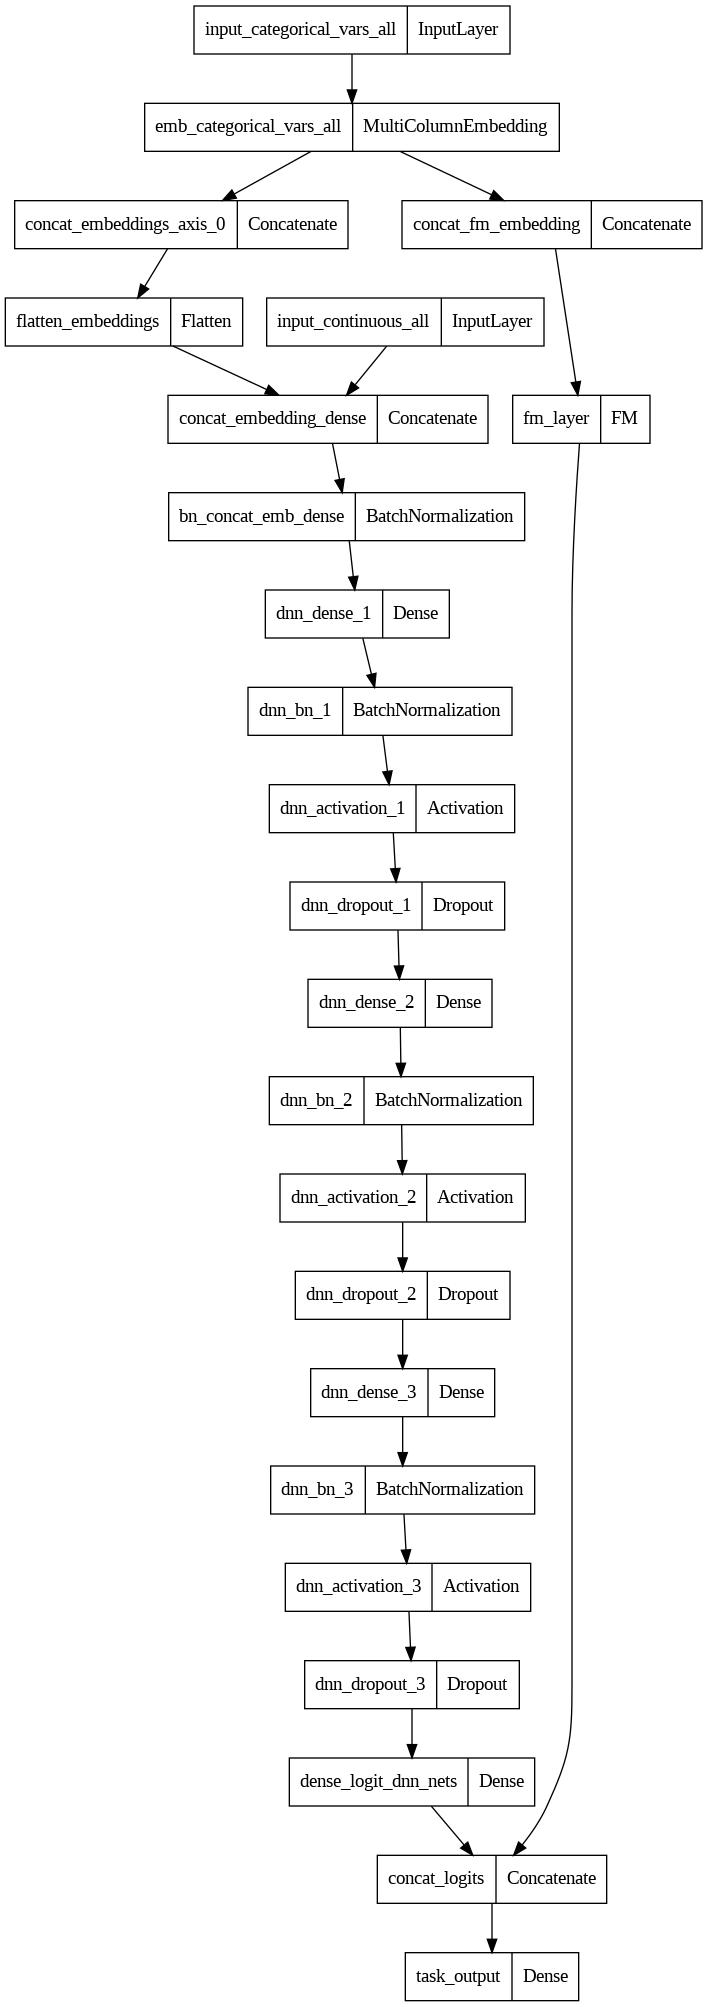

Ensemble CV score: 0.9750

CPU times: user 8h 48min 40s, sys: 1h 7min 38s, total: 9h 56min 19s
Wall time: 4h 20min 28s


In [8]:
%%time
def train_model(X, y, nn=['dnn_nets'], model_n='model_1'):
    print("Data shape:", X.shape, "\n")
    skf = StratifiedKFold(n_splits=CFG.folds, shuffle=True, random_state=42)
    oof = np.zeros(len(X))
    models = []
    
    for fi, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        print("#"*25)
        print(f"### Fold {fi+1}/{CFG.folds} ...")
        print("#"*25)

        K.clear_session()
        CFG.conf = CFG.conf._replace(nets=nn)
        model = DeepTable(config=CFG.conf)
        model.fit(X.iloc[train_idx], y.iloc[train_idx],
                  validation_data=(X.iloc[valid_idx], y.iloc[valid_idx]),
                  callbacks=CFG.callbacks, batch_size=CFG.batch_size,
                  epochs=CFG.epochs, verbose=CFG.FIT_VERBOSE)
        models.append(model)

        # Save model
        os.makedirs(f"/kaggle/working/models/fold{fi}_{model_n}", exist_ok=True)
        os.makedirs(f"/tmp/workdir/kaggle/working/models/fold{fi}_{model_n}", exist_ok=True)
        model.save(f"/kaggle/working/models/fold{fi}_{model_n}")
        os.system(f"cp -r /kaggle/working/models/fold{fi}_{model_n}/* /tmp/workdir/kaggle/working/models/fold{fi}_{model_n}/")
        # Avoid some errors
        with K.name_scope(CFG.optimizer.__class__.__name__):
            for j, var in enumerate(CFG.optimizer.weights):
                name = "variable{}".format(j)
                CFG.optimizer.weights[j] = tf.Variable(var, name=name)
        CFG.conf = CFG.conf._replace(optimizer=CFG.optimizer)

        oof_pred = model.predict_proba(X.iloc[valid_idx], verbose=1, batch_size=512)[:, 1]
        m = np.round(roc_auc_score(y.iloc[valid_idx], oof_pred), 4)
        print(f"{Fore.GREEN}{Style.BRIGHT}\nFold {fi+1} | score: {m:.4f}{Style.RESET_ALL}\n")
        oof[valid_idx] = oof_pred

    m_all = np.round(roc_auc_score(y, oof), 4)
    print(f"{Fore.BLUE}{Style.BRIGHT}Overall CV score: {m_all:.4f}{Style.RESET_ALL}\n")
    display(plot_model(model.get_model().model))
    return models, oof

if CFG.TRAIN==True:
    models_1, oof_1 = train_model(X, y, nn=['dnn_nets','fg_nets'], model_n='model_1')
    models_2, oof_2 = train_model(X, y, nn=['dnn_nets','fm_nets'], model_n='model_2')    

    if 'models_2' in globals():
        models = models_1 + models_2
        oof_ensemble = np.mean((oof_1, oof_2), axis=0)
        m_ensemble = np.round(roc_auc_score(y, oof_ensemble), 4)
        print(f"{Fore.MAGENTA}{Style.BRIGHT}Ensemble CV score: {m_ensemble:.4f}{Style.RESET_ALL}\n")
        oof_df = pd.DataFrame({'id': train_id, 'oof_pred': oof_ensemble})
        oof_df.to_csv('oof_preds.csv', index=False)
    else:
        models = models_1
        oof_df = pd.DataFrame({'id': train_id, 'oof_pred': oof_1})
        oof_df.to_csv('oof_preds.csv', index=False)
    clean_memory()

# Create Submission

In [9]:
# Load models
def load_model(paths):
    models = []
    for fold in sorted(os.listdir(paths)):
        path = os.path.join(paths, fold)
        for file in os.listdir(path):
            if file.endswith('.h5'):
                models.append(DeepTable.load(path, file))
    return models

models = load_model("/kaggle/working/models")
print("\nmodels:", models)

08-24 01:01:48 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/models/fold0_model_1/dnn_nets+fg_nets.h5.
2 Physical GPUs, 2 Logical GPUs
08-24 01:01:52 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/models/fold0_model_2/dnn_nets+fm_nets.h5.
2 Physical GPUs, 2 Logical GPUs
08-24 01:01:54 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/models/fold1_model_1/dnn_nets+fg_nets.h5.
2 Physical GPUs, 2 Logical GPUs
08-24 01:01:58 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/models/fold1_model_2/dnn_nets+fm_nets.h5.
2 Physical GPUs, 2 Logical GPUs
08-24 01:02:01 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/models/fold2_model_1/dnn_nets+fg_nets.h5.
2 Physical GPUs, 2 Logical GPUs
08-24 01:02:05 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/models/fold2_model_2/dnn_nets+fm_nets.h5.
2 Physical GPUs, 2 Logical GPUs
08-24 01:02:09 I deeptables.m.deeptable.py 818 - Load model from

In [10]:
# Get feature importance
models_num = len(models) // CFG.folds
if models_num == 1:
    dt_explainer = DeepTablesExplainer(models[0], X_test, num_samples=100)
    shap_values = dt_explainer.get_shap_values(X_test[:10], nsamples='auto')    
elif models_num == 2:
    dt_explainer_1 = DeepTablesExplainer(models[0], X_test, num_samples=100)
    shap_values_1 = dt_explainer_1.get_shap_values(X_test[:10], nsamples='auto')
    dt_explainer_2 = DeepTablesExplainer(models[CFG.folds], X_test, num_samples=100)
    shap_values_2 = dt_explainer_2.get_shap_values(X_test[:10], nsamples='auto')
    shap_values = np.mean(np.array([shap_values_1, shap_values_2]), axis=0)

08-24 01:02:47 I deeptables.m.deeptable.py 685 - Perform prediction...
08-24 01:02:47 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-24 01:02:48 I deeptables.m.preprocessor.py 251 - transform_X taken 0.1055135726928711s
08-24 01:02:48 I deeptables.m.deepmodel.py 130 - Performing predictions...
08-24 01:02:48 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGForPandas, batch_size=128, shuffle=False, drop_remainder=False
08-24 01:02:48 I deeptables.m.deeptable.py 559 - predict_proba taken 0.8483426570892334s


  0%|          | 0/10 [00:00<?, ?it/s]

08-24 01:02:48 I deeptables.m.deeptable.py 685 - Perform prediction...
08-24 01:02:48 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-24 01:02:48 I deeptables.m.preprocessor.py 251 - transform_X taken 0.10191059112548828s
08-24 01:02:48 I deeptables.m.deepmodel.py 130 - Performing predictions...
08-24 01:02:48 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGForPandas, batch_size=128, shuffle=False, drop_remainder=False
08-24 01:02:49 I deeptables.m.deeptable.py 559 - predict_proba taken 0.42837977409362793s
08-24 01:02:49 I deeptables.m.deeptable.py 685 - Perform prediction...
08-24 01:02:49 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-24 01:02:57 I deeptables.m.preprocessor.py 251 - transform_X taken 7.690576791763306s
08-24 01:02:57 I deeptables.m.deepmodel.py 130 - Performing predictions...
08-24 01:02:57 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGForPandas, batch_size=128, shuffle=False, drop_remain

  0%|          | 0/10 [00:00<?, ?it/s]

08-24 01:05:55 I deeptables.m.deeptable.py 685 - Perform prediction...
08-24 01:05:55 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-24 01:05:55 I deeptables.m.preprocessor.py 251 - transform_X taken 0.10118246078491211s
08-24 01:05:55 I deeptables.m.deepmodel.py 130 - Performing predictions...
08-24 01:05:55 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGForPandas, batch_size=128, shuffle=False, drop_remainder=False
08-24 01:05:55 I deeptables.m.deeptable.py 559 - predict_proba taken 0.1306314468383789s
08-24 01:05:55 I deeptables.m.deeptable.py 685 - Perform prediction...
08-24 01:05:55 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-24 01:06:03 I deeptables.m.preprocessor.py 251 - transform_X taken 7.730869770050049s
08-24 01:06:03 I deeptables.m.deepmodel.py 130 - Performing predictions...
08-24 01:06:03 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGForPandas, batch_size=128, shuffle=False, drop_remaind

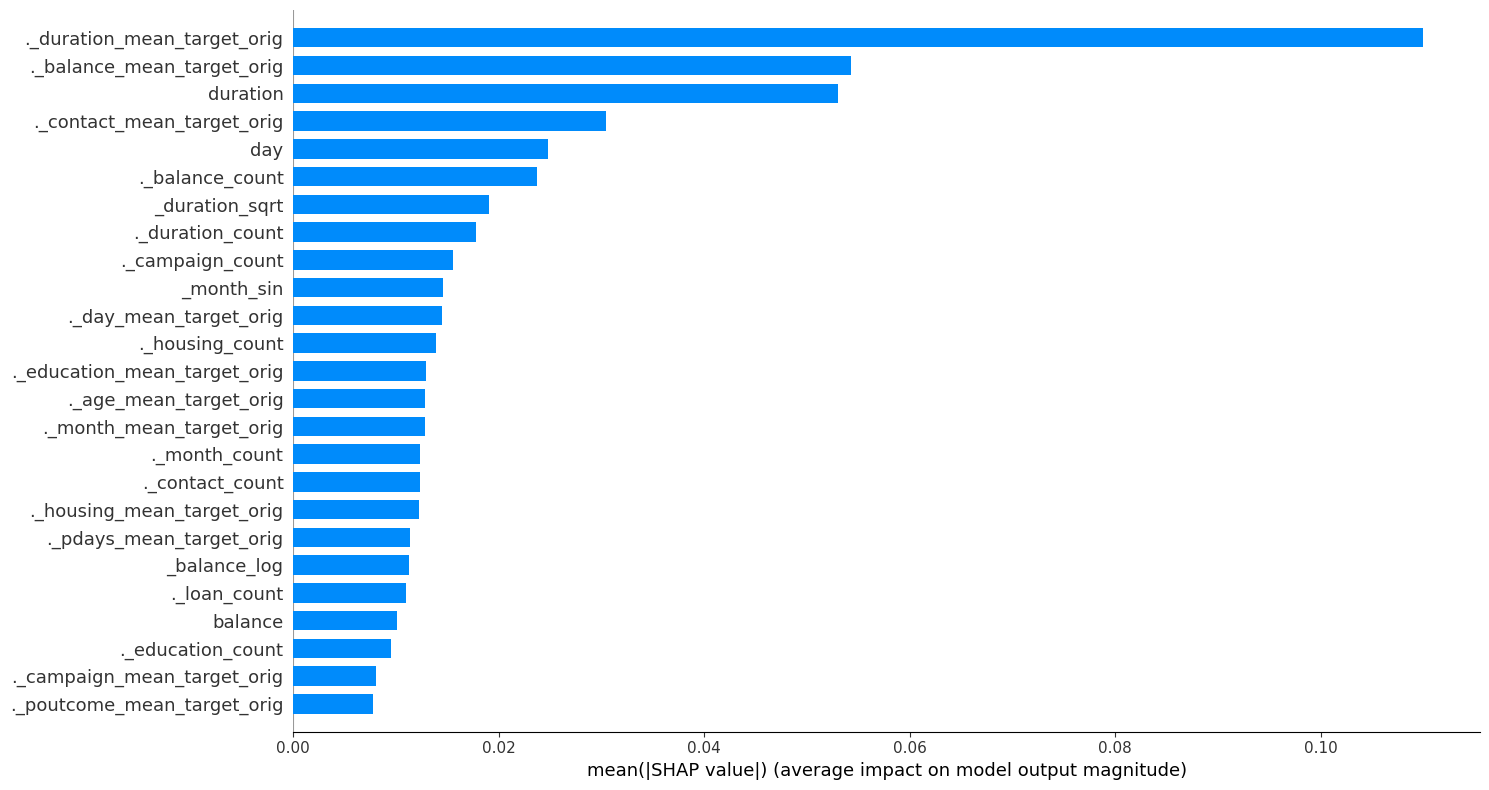

In [11]:
# Plot feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=25, plot_size=(15,8))

In [12]:
# Inference
class AvgModel:
    def __init__(self, models: list[BaseEstimator]):
        self.models = models
    def predict(self, X: ArrayLike):
        preds = []
        for model in self.models:
            pred = model.predict_proba(X, verbose=1, batch_size=512)[:, 1]
            preds.append(pred)
        return np.mean(preds, axis=0)

avg_model = AvgModel(models)
test_pred = avg_model.predict(X_test)

08-24 01:08:53 I deeptables.m.deeptable.py 685 - Perform prediction...
08-24 01:08:53 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-24 01:09:02 I deeptables.m.preprocessor.py 251 - transform_X taken 9.062047481536865s
08-24 01:09:02 I deeptables.m.deepmodel.py 130 - Performing predictions...
08-24 01:09:02 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGForPandas, batch_size=512, shuffle=False, drop_remainder=False
489/489 [==============================] - 3s 7ms/step
08-24 01:09:06 I deeptables.m.deeptable.py 559 - predict_proba taken 13.174411296844482s
08-24 01:09:06 I deeptables.m.deeptable.py 685 - Perform prediction...
08-24 01:09:06 I deeptables.m.preprocessor.py 244 - Transform [X]...
08-24 01:09:15 I deeptables.m.preprocessor.py 251 - transform_X taken 9.148316144943237s
08-24 01:09:15 I deeptables.m.deepmodel.py 130 - Performing predictions...
08-24 01:09:15 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGF

In [13]:
sub = pd.read_csv("/kaggle/input/playground-series-s5e8/sample_submission.csv")
sub.y = test_pred
sub.to_csv("submission.csv", index=False)
sub.head()

,id,y
0,750000,0.002438
1,750001,0.070396
2,750002,0.000021
3,750003,0.000025
4,750004,0.006788
